# 05 - Model Evaluation & Conclusion

Evaluation of the final LightGBM model on the held-out test set: classification report, ROC curve, confusion matrix and feature importance.

In [1]:
import sys
sys.path.append("..")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

from src.visualization import plot_importance

In [2]:
# Chargement des deux modèles sauvegardés à la fin du notebook 04
lgbm_model = joblib.load("../models/lgbm_model.pkl")
voting_clf = joblib.load("../models/voting_clf.pkl")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

# Évaluation du Voting Classifier (modèle d'ensemble)
y_pred_voting = voting_clf.predict(X_test)
print("=== Performance du Voting Classifier ===")
print(classification_report(y_test, y_pred_voting))

=== Performance du Voting Classifier ===
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.82      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



**Metrics**
- Accuracy = (TP+TN) / (TP+TN+FP+FN)
- Precision = TP / (TP+FP)
- Recall = TP / (TP+FN)
- F1 = 2 x (Precision x Recall) / (Precision + Recall)
- ROC curve: TPR vs FPR across thresholds

In [3]:
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.82      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



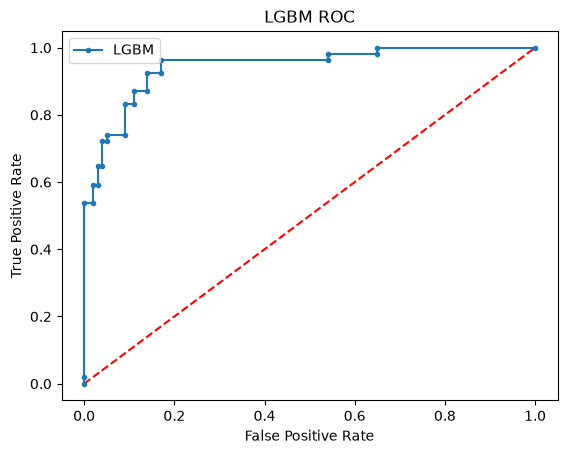

In [4]:
lgbm_roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot([0, 1], [0, 1], 'r--')
plt.plot(fpr, tpr, marker='.', label='LGBM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("LGBM ROC")
plt.legend()
plt.show()

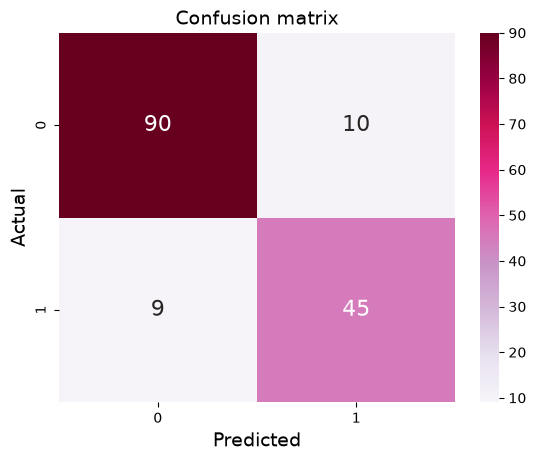

In [5]:
cnf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="PuRd", annot_kws={"size": 16})
plt.title('Confusion matrix', size=14)
plt.ylabel('Actual', size=14)
plt.xlabel('Predicted', size=14)
plt.show()

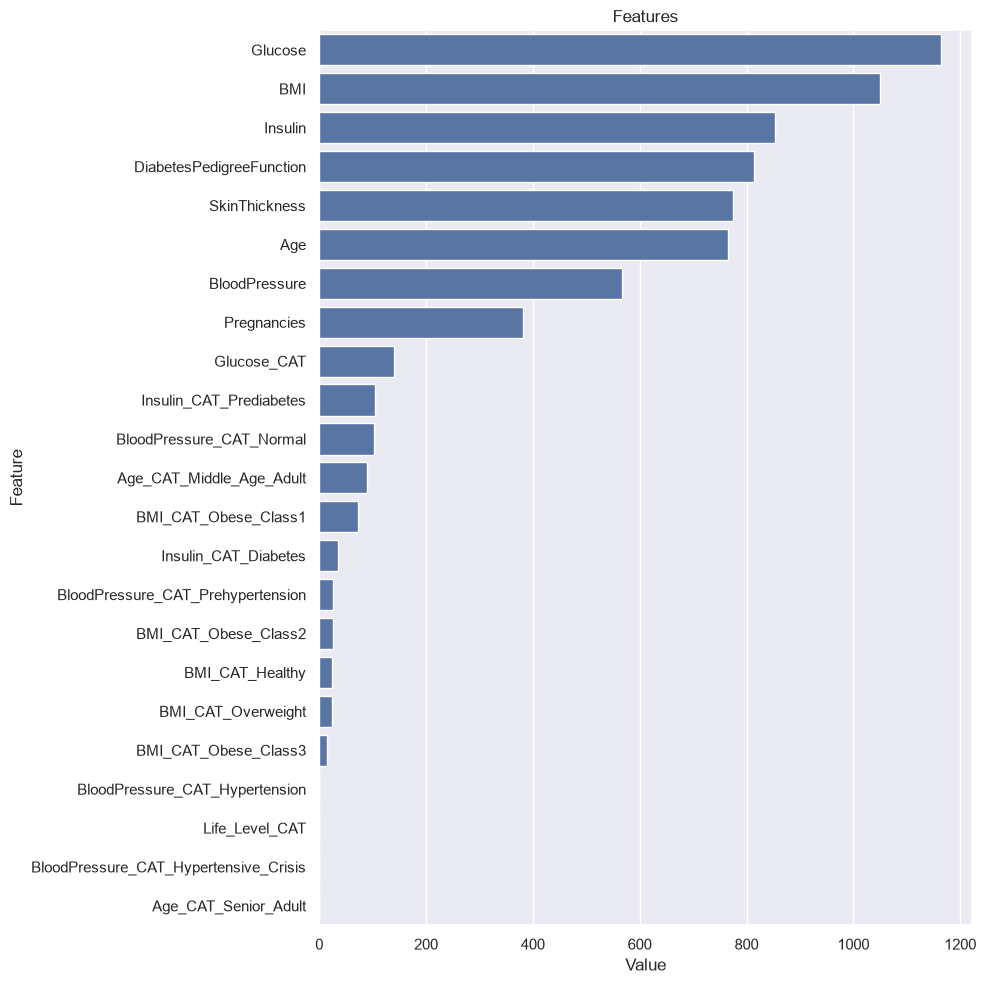

In [6]:
plot_importance(lgbm_model, X_test)

## Conclusion

`Glucose`, `Insulin`, and `BMI` are the strongest drivers of the diabetes outcome. Engineered features have a smaller but non-negligible impact on accuracy, and preprocessing (missing-value handling, outlier capping, scaling) matters more than model choice alone.

**Effectiveness of preprocessing on training accuracy:**

| Algorithm | Baseline (no preprocessing) | Baseline (with preprocessing) | Optimized |
|---|---|---|---|
| LR | 0.7671 | 0.8731 | - |
| KNN | 0.7182 | 0.8535 | 0.8616 |
| CART | 0.7312 | 0.8354 | 0.8615 |
| RF | 0.7752 | 0.8893 | 0.8828 |
| GBM | 0.7638 | 0.8893 | - |
| XGBoost | 0.7508 | 0.8909 | 0.8974 |
| LightGBM | 0.7378 | 0.8925 | 0.9007 |

LightGBM gives the best accuracy, by a small margin over XGBoost, after hyperparameter tuning.